In [1]:
!pip install -q transformers datasets torch scikit-learn matplotlib tqdm

# FinBert - Pre Train model for Finance

  1. Finbert-ESG
  
    - Four classifications: Ambiental, Social, Gobernanza o Ninguna.

In [6]:
# Simple one-shot demo: classify short financial paragraphs as E / S / G / None
# Run in Colab or local Python (requires: pip install transformers torch)
import torch
from transformers import pipeline

# Use GPU if available
device = 0 if torch.cuda.is_available() else -1

# Load FinBERT-ESG sequence classification pipeline (no fine-tuning required)
clf = pipeline(
    "text-classification",
    model="yiyanghkust/finbert-esg",
    tokenizer="yiyanghkust/finbert-esg",
    device=device,
    return_all_scores=False  # set True if you want scores for all labels
)

config.json:   0%|          | 0.00/781 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [7]:
# Very short example texts (one-shot trial)
examples = [
    "The company committed to net zero and cut its scope 1 emissions by 40% this year.",
    "Several factory workers reported unsafe working conditions and lack of protective gear.",
    "Board members are related-party and disclosure practices are weak.",
    "Revenue grew 12% this quarter driven by new product sales."
]

# Run inference and print results
results = clf(examples, truncation=True)
for text, res in zip(examples, results):
    label = res['label']
    score = res.get('score', None)
    print(f"Text: {text}\n -> Predicted: {label}  (score: {score:.3f})\n")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Text: The company committed to net zero and cut its scope 1 emissions by 40% this year.
 -> Predicted: Environmental  (score: 0.991)

Text: Several factory workers reported unsafe working conditions and lack of protective gear.
 -> Predicted: Social  (score: 0.987)

Text: Board members are related-party and disclosure practices are weak.
 -> Predicted: Governance  (score: 0.945)

Text: Revenue grew 12% this quarter driven by new product sales.
 -> Predicted: None  (score: 0.995)



  2. Finbert-ESG 9 categories
  
    - Nine classifications: Climate Change, Natural Capital, Pollution & Waste, Human Capital, Product Liability, Community Relations, Corporate Governance, Business Ethics & Values, or Non-ESG

In [8]:
# Load FinBERT-ESG sequence classification pipeline (no fine-tuning required)
clf = pipeline(
    "text-classification",
    model="yiyanghkust/finbert-esg-9-categories",
    tokenizer="yiyanghkust/finbert-esg-9-categories",
    device=device,
    return_all_scores=False  # set True if you want scores for all labels
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cuda:0


In [9]:
# Very short example texts (one-shot trial)
examples = [
    "The company committed to net zero and cut its scope 1 emissions by 40% this year.",
    "Several factory workers reported unsafe working conditions and lack of protective gear.",
    "Board members are related-party and disclosure practices are weak.",
    "Revenue grew 12% this quarter driven by new product sales."
]

# Run inference and print results
results = clf(examples, truncation=True)
for text, res in zip(examples, results):
    label = res['label']
    score = res.get('score', None)
    print(f"Text: {text}\n -> Predicted: {label}  (score: {score:.3f})\n")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Text: The company committed to net zero and cut its scope 1 emissions by 40% this year.
 -> Predicted: Climate Change  (score: 0.993)

Text: Several factory workers reported unsafe working conditions and lack of protective gear.
 -> Predicted: Human Capital  (score: 0.994)

Text: Board members are related-party and disclosure practices are weak.
 -> Predicted: Corporate Governance  (score: 0.991)

Text: Revenue grew 12% this quarter driven by new product sales.
 -> Predicted: Non-ESG  (score: 0.993)



# Image Models

  1. Vision Transformer pretrained on ImageNet (works out-of-the-box for image classification) - google/vit-base-patch16-224

  - This model looks at an image by cutting it into small pieces (“patches”) and then figures out what it shows — for example, a cat, a car, or a tree. It works kind of like how people read, piece by piece, and then understand the full picture.

In [10]:
!pip install -q pillow

In [11]:
# Colab cell: ViT image classification (PyTorch)
from PIL import Image
import requests
from io import BytesIO

device = 0 if torch.cuda.is_available() else -1
clf = pipeline("image-classification", model="google/vit-base-patch16-224", device=device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cuda:0


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Load CIFAR-10
cifar10 = datasets.CIFAR10(root="./data", train=False, download=True, transform=transforms.ToTensor())


100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


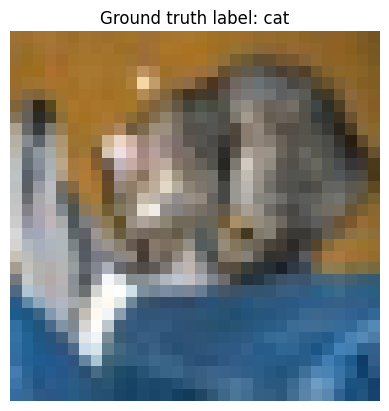

Top predictions (ViT):
tabby, tabby cat: 0.1773
Egyptian cat: 0.0552
tiger cat: 0.0429
velvet: 0.0395
polecat, fitch, foulmart, foumart, Mustela putorius: 0.0273


In [13]:
# Pick one sample image and label
img, label = cifar10[0]

# Show the image
plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title(f"Ground truth label: {cifar10.classes[label]}")
plt.show()

# Convert tensor -> PIL Image for Hugging Face pipeline
from torchvision.transforms.functional import to_pil_image
img_pil = to_pil_image(img)

# Run classification
results = clf(img_pil, top_k=5)
print("Top predictions (ViT):")
for r in results:
    print(f"{r['label']}: {r['score']:.4f}")

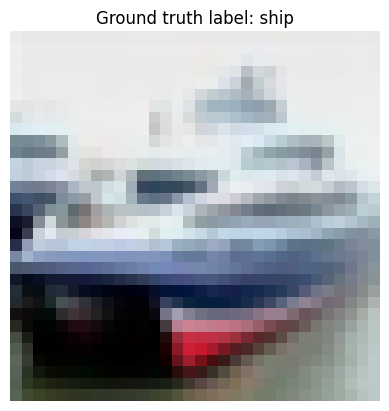

Top predictions (ViT):
speedboat: 0.5436
lifeboat: 0.0630
container ship, containership, container vessel: 0.0480
trimaran: 0.0335
liner, ocean liner: 0.0319


In [14]:
# Pick one sample image and label
img2, label2 = cifar10[1]

# Show the image
plt.imshow(np.transpose(img2.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title(f"Ground truth label: {cifar10.classes[label2]}")
plt.show()

# Convert tensor -> PIL Image for Hugging Face pipeline
from torchvision.transforms.functional import to_pil_image
img_pil2 = to_pil_image(img2)

# Run classification
results2 = clf(img_pil2, top_k=5)
print("Top predictions (ViT):")
for r in results2:
    print(f"{r['label']}: {r['score']:.4f}")

  2. Object detection pretrained -DETR panoptic segmentation (detects bounding boxes + labels on COCO classes) - facebook/detr-resnet-50

  - This model not only sees what is in a picture, but also where each object is located. It can say “there’s a dog on the left” and “a ball on the right,” making it useful for identifying multiple things at once.

In [15]:
!pip install -q torchvision

In [16]:
# Import necessary libraries
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from transformers import AutoFeatureExtractor, DetrForObjectDetection
from google.colab import files
import requests # Added for a default image if no upload

# --- 1. Load Image ---
# Upload an image from your computer or use a default one
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert("RGB")

# --- 2. Load Model ---
# We use DetrForObjectDetection as it's more direct for this task
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

Saving prueba_sala.jpg to prueba_sala (1).jpg


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/detr/feature_extraction_detr.py:40: FutureWarning: The class DetrFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use DetrImageProcessor instead.
  warnings.warn(


model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

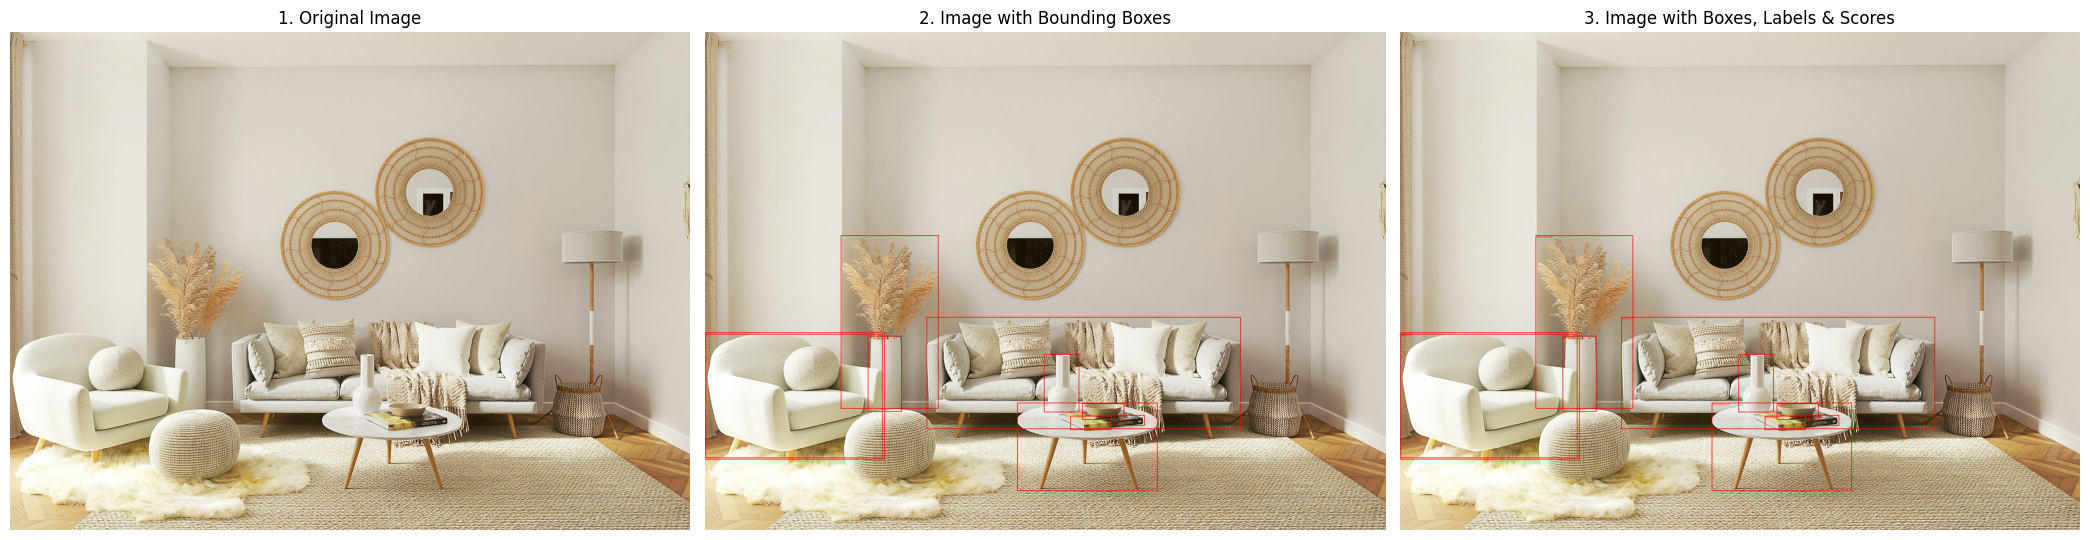


Detected objects:
• vase (score: 0.90)
• couch (score: 0.78)
• remote (score: 0.55)
• potted plant (score: 0.97)
• vase (score: 0.93)
• chair (score: 1.00)
• couch (score: 1.00)
• remote (score: 0.98)
• bowl (score: 0.97)
• dining table (score: 0.53)


In [18]:
# --- 3. Process Image and Get Predictions ---
# Prepare image for the model
inputs = feature_extractor(images=img, return_tensors="pt")

# Run model
with torch.no_grad():
    outputs = model(**inputs)

# Post-process the output to get bounding boxes, labels, and scores
# We use a threshold to filter out low-confidence detections
target_sizes = torch.tensor([img.size[::-1]])
results = feature_extractor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

# --- 4. Prepare Images for Display ---

# Create copies of the original image to draw on
img_boxes = img.copy()
img_boxes_labels = img.copy()

# Initialize drawing contexts
draw_boxes = ImageDraw.Draw(img_boxes)
draw_boxes_labels = ImageDraw.Draw(img_boxes_labels)

# Loop through detected objects
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    label_text = model.config.id2label[label.item()]

    # Draw bounding box on the first copy
    draw_boxes.rectangle(box, outline="red", width=3)

    # Draw bounding box and label on the second copy
    draw_boxes_labels.rectangle(box, outline="red", width=3)
    draw_boxes_labels.text((box[0], box[1]), f"{label_text}: {score:.2f}", fill="red")

# --- 5. Display the Three Images ---
plt.figure(figsize=(21, 7))

# Plot 1: Original Image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axis("off")
plt.title("1. Original Image")

# Plot 2: Image with Bounding Boxes
plt.subplot(1, 3, 2)
plt.imshow(img_boxes)
plt.axis("off")
plt.title("2. Image with Bounding Boxes")

# Plot 3: Image with Bounding Boxes and Labels
plt.subplot(1, 3, 3)
plt.imshow(img_boxes_labels)
plt.axis("off")
plt.title("3. Image with Boxes, Labels & Scores")

plt.tight_layout()
plt.show()

# Optional: Print detected objects to console
print("\nDetected objects:")
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    print(f"• {model.config.id2label[label.item()]} (score: {score:.2f})")

Saving supermercado.jpg to supermercado.jpg


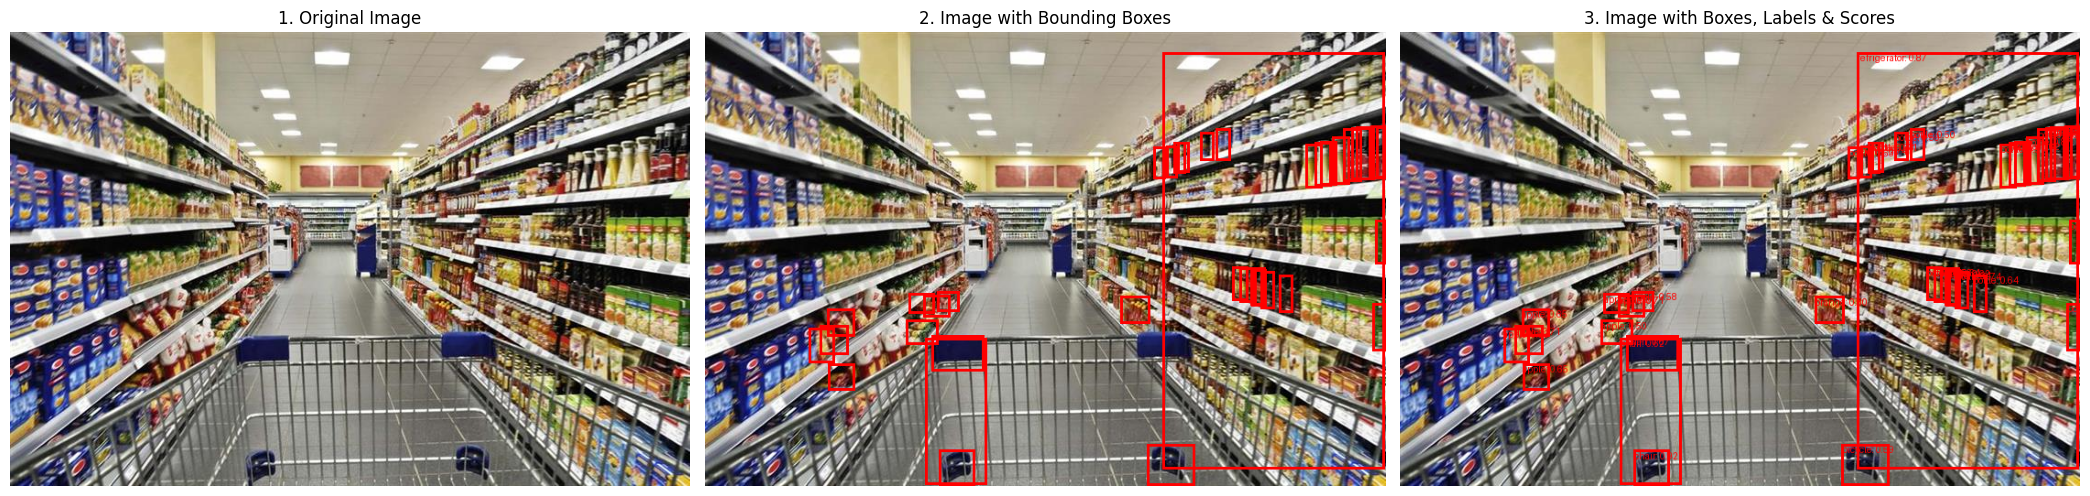


Detected objects:
• apple (score: 0.53)
• bottle (score: 0.74)
• bottle (score: 0.59)
• bottle (score: 0.64)
• apple (score: 0.71)
• bottle (score: 0.64)
• bottle (score: 0.74)
• bottle (score: 0.90)
• bottle (score: 0.77)
• bottle (score: 0.56)
• bottle (score: 0.87)
• bottle (score: 0.63)
• chair (score: 0.67)
• apple (score: 0.65)
• apple (score: 0.58)
• apple (score: 0.50)
• bottle (score: 0.57)
• bottle (score: 0.62)
• bottle (score: 0.71)
• chair (score: 0.62)
• apple (score: 0.70)
• chair (score: 0.92)
• apple (score: 0.65)
• bottle (score: 0.88)
• bottle (score: 0.82)
• bottle (score: 0.82)
• bottle (score: 0.64)
• bottle (score: 0.62)
• bottle (score: 0.85)
• apple (score: 0.71)
• bottle (score: 0.65)
• bottle (score: 0.63)
• orange (score: 0.80)
• bottle (score: 0.51)
• bicycle (score: 0.59)
• refrigerator (score: 0.87)
• bottle (score: 0.50)


In [19]:
# --- 1. Load Image ---
# Upload an image from your computer or use a default one
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert("RGB")

# --- 3. Process Image and Get Predictions ---
# Prepare image for the model
inputs = feature_extractor(images=img, return_tensors="pt")

# Run model
with torch.no_grad():
    outputs = model(**inputs)

# Post-process the output to get bounding boxes, labels, and scores
# We use a threshold to filter out low-confidence detections
target_sizes = torch.tensor([img.size[::-1]])
results = feature_extractor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

# --- 4. Prepare Images for Display ---

# Create copies of the original image to draw on
img_boxes = img.copy()
img_boxes_labels = img.copy()

# Initialize drawing contexts
draw_boxes = ImageDraw.Draw(img_boxes)
draw_boxes_labels = ImageDraw.Draw(img_boxes_labels)

# Loop through detected objects
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    label_text = model.config.id2label[label.item()]

    # Draw bounding box on the first copy
    draw_boxes.rectangle(box, outline="red", width=3)

    # Draw bounding box and label on the second copy
    draw_boxes_labels.rectangle(box, outline="red", width=3)
    draw_boxes_labels.text((box[0], box[1]), f"{label_text}: {score:.2f}", fill="red")

# --- 5. Display the Three Images ---
plt.figure(figsize=(21, 7))

# Plot 1: Original Image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axis("off")
plt.title("1. Original Image")

# Plot 2: Image with Bounding Boxes
plt.subplot(1, 3, 2)
plt.imshow(img_boxes)
plt.axis("off")
plt.title("2. Image with Bounding Boxes")

# Plot 3: Image with Bounding Boxes and Labels
plt.subplot(1, 3, 3)
plt.imshow(img_boxes_labels)
plt.axis("off")
plt.title("3. Image with Boxes, Labels & Scores")

plt.tight_layout()
plt.show()

# Optional: Print detected objects to console
print("\nDetected objects:")
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    print(f"• {model.config.id2label[label.item()]} (score: {score:.2f})")



  3. Image captioning (vision→text) — Salesforce/blip2-opt-2.7b (BLIP-2)

  - This is a smart model that can describe images with words or answer questions about them. For example, if you show it a photo of a cat on a sofa and ask “What is the cat doing?”, it can answer “The cat is sitting on the sofa.”

- This model is a mini version of 8bits due to the high memory neccesary for the whole model

In [ ]:
# Install required libraries in Colab
!pip install -q bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 11.3 MB/s eta 0:00:00


In [ ]:
import torch
from PIL import Image
import requests
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import matplotlib.pyplot as plt

# --- 1. Setup ---
# Set device to GPU if available, otherwise CPU
# NOTE: For 8-bit, device_map="auto" handles this better than manually setting the device.
print("Checking for CUDA availability...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- KEY CHANGE: Load the model in 8-bit precision ---
# This significantly reduces memory usage.
# We use device_map="auto" to let accelerate handle placing the model on the GPU.
print("Loading model in 8-bit precision...")
processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    load_in_8bit=True,
    device_map="auto"
)
print("Model loaded.")

# Load a sample image
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# --- 2. Example 1: Image Captioning ---
print("\n--- Example 1: Generating a Description ---")

# We don't need to specify torch_dtype for inputs with a quantized model
inputs = processor(images=image, return_tensors="pt").to(device)

generated_ids = model.generate(**inputs, max_new_tokens=50)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(f"Generated Caption: {generated_text}")

# --- 3. Example 2: Visual Question Answering (VQA) ---
print("\n--- Example 2: Answering Questions About the Image ---")

def ask_question(question):
    """A helper function to ask a question and print the answer."""
    prompt = f"Question: {question} Answer:"

    # Process both image and text
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

    generated_ids = model.generate(**inputs, max_new_tokens=20)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    print(f"Q: {question}")
    print(f"A: {generated_text}")
    print("-" * 30)

ask_question("How many cats are in the picture?")
ask_question("What are the cats doing?")

Checking for CUDA availability...
Using device: cpu
Loading model in 8-bit precision...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

- Model Smaller with 16-bit

In [ ]:
import torch
from PIL import Image
import requests
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import matplotlib.pyplot as plt

# --- 1. Setup ---
# Set device to GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the processor and model from Hugging Face
# Using float16 for less memory usage
processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16
).to(device)

# Load a sample image from an open-source dataset (COCO)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Display the image we're working with
print("--- Displaying Source Image ---")
plt.imshow(image)
plt.title("Source Image")
plt.axis("off")
plt.show()


Using device: cpu


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# --- 2. Example 1: Image Captioning ---

print("\n--- Example 1: Generating a Description ---")

# Prepare the image for the model using the processor
# No text prompt is needed for basic captioning
inputs = processor(images=image, return_tensors="pt").to(device, torch.float16)

# Generate a caption
generated_ids = model.generate(**inputs, max_new_tokens=50)

# Decode the generated IDs to text
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

# Print the result
print(f"Generated Caption: {generated_text}")

In [ ]:
# --- 3. Example 2: Visual Question Answering (VQA) ---

print("\n--- Example 2: Answering Questions About the Image ---")

def ask_question(question):
    """A helper function to ask a question and print the answer."""
    # Format the prompt with the question
    prompt = f"Question: {question} Answer:"

    # Process both the image and the text prompt
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device, torch.float16)

    # Generate an answer
    generated_ids = model.generate(**inputs, max_new_tokens=20)

    # Decode and print the result
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    print(f"Q: {question}")
    print(f"A: {generated_text}")
    print("-" * 30)

# Ask a few different questions about the image
ask_question("How many cats are in the picture?")
ask_question("What color is the couch?")
ask_question("What are the cats doing?")

3.1 Ligther version can be git-base-coco

In [20]:
import torch
from PIL import Image
import requests
from transformers import AutoProcessor, AutoModelForCausalLM
import matplotlib.pyplot as plt

In [21]:
# --- 1. Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "microsoft/git-base-coco"
print(f"Loading smaller model: {model_name}")

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
print("Model loaded.")

Using device: cuda
Loading smaller model: microsoft/git-base-coco


preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/707M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded.


In [22]:
# Load the same sample image
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# --- 2. Example 1: Image Captioning  ---
print("\n--- Example 1: Generating a Description ---")

# For captioning, we only process the image
caption_inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = caption_inputs.pixel_values

generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(f"Generated Caption: {generated_text}")


--- Example 1: Generating a Description ---
Generated Caption: two cats sleeping on a pink blanket next to remotes.


In [23]:
# --- 3. Example 2: Visual Question Answering (VQA) ---
print("\n--- Example 2: Answering Questions About the Image ---")

def ask_question_git(image, question):
    """
    A helper function for the GIT model that uses the correct
    combined-modality processing and isolates the answer.
    """
    # BEST LOGIC: Process the image and text question TOGETHER.
    # This is the crucial step that ensures the model understands
    # it needs to answer a question about this specific image.
    inputs = processor(images=image, text=question, return_tensors="pt").to(device)

    # Get the length of the question tokens
    prompt_length = inputs.input_ids.shape[1]

    # Generate the answer
    generated_ids = model.generate(**inputs, max_new_tokens=50)

    # Slice the output to remove the question and get only the answer
    answer_ids = generated_ids[:, prompt_length:]

    # Decode the answer
    answer = processor.batch_decode(answer_ids, skip_special_tokens=True)[0].strip()

    print(f"Q: {question}")
    print(f"A: {answer}")
    print("-" * 30)

# Use the corrected helper function to ask questions
ask_question_git(image, "how many cats are in the picture?")
ask_question_git(image, "what are the cats doing?")
ask_question_git(image, "what color is the remote control?")


--- Example 2: Answering Questions About the Image ---
Q: how many cats are in the picture?
A: 
------------------------------
Q: what are the cats doing?
A: the remotes are lying on the couch.
------------------------------
Q: what color is the remote control?
A: 
------------------------------


  4. Semantic segmentation — nvidia/segformer-b0-finetuned-ade-512-512

  - Its purpose is to assign a class label to every pixel in an image, making it useful for applications such as autonomous driving, robotics navigation, urban scene understanding, and image editing.

Loading the segmentation model (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Device set to use cuda:0


Model loaded successfully.

Please upload an image file.


Saving prueba_sala.jpg to prueba_sala.jpg

Successfully loaded image: prueba_sala.jpg
Running segmentation on the image...
Segmentation complete.


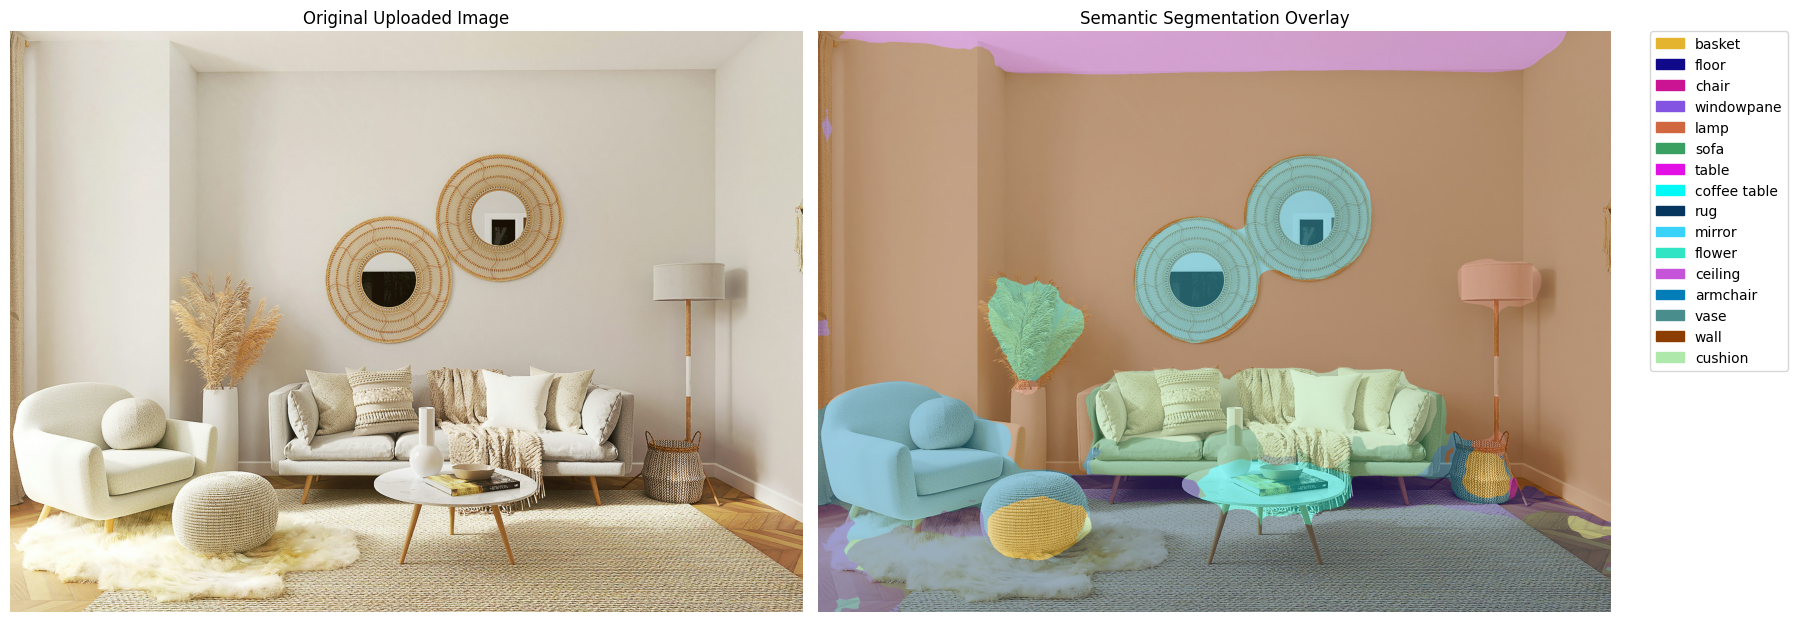

In [1]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import pipeline
from google.colab import files # Import the files module for uploading

# --- 1. Setup Model ---

# Set device to GPU if available for faster processing
device = 0 if torch.cuda.is_available() else -1

# Load the segmentation pipeline with the specified SegFormer model
print("Loading the segmentation model (this may take a moment)...")
segmenter = pipeline("image-segmentation", model="nvidia/segformer-b0-finetuned-ade-512-512", device=device)
print("Model loaded successfully.")

# --- 2. Upload and Load Your Image ---
print("\nPlease upload an image file.")
uploaded = files.upload()

# Check if a file was uploaded
if not uploaded:
    print("\nNo file uploaded. Please run the cell again to upload an image.")
else:
    # Get the filename of the uploaded file
    image_path = list(uploaded.keys())[0]
    # Open the image
    image = Image.open(image_path).convert("RGB")
    print(f"\nSuccessfully loaded image: {image_path}")


    # --- 3. Run Inference ---

    # Get the segmentation masks from the model
    print("Running segmentation on the image...")
    masks = segmenter(image)
    print("Segmentation complete.")


    # --- 4. Visualize the Results ---

    # Create a color map for visualization
    unique_labels = {mask['label'] for mask in masks}
    color_map = {label: list(np.random.choice(range(256), size=3)) for label in unique_labels}

    # Create an empty RGB image to draw the segmentation map
    segmentation_map = np.zeros((image.height, image.width, 3), dtype=np.uint8)

    # Overlay each mask with its corresponding color
    for mask_info in masks:
        label = mask_info['label']
        mask = np.array(mask_info['mask'])
        color = color_map[label]
        segmentation_map[mask > 0] = color

    # Create a blended image for a nice overlay effect
    alpha = 0.6  # Transparency of the overlay
    blended_image = Image.fromarray(
        (alpha * np.array(image) + (1 - alpha) * segmentation_map).astype(np.uint8)
    )

    # --- 5. Display the Images and a Legend ---

    fig, axs = plt.subplots(1, 2, figsize=(18, 9))

    axs[0].imshow(image)
    axs[0].axis('off')
    axs[0].set_title("Original Uploaded Image")

    axs[1].imshow(blended_image)
    axs[1].axis('off')
    axs[1].set_title("Semantic Segmentation Overlay")

    patches = [mpatches.Patch(color=np.array(color)/255, label=label) for label, color in color_map.items()]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()



Please upload an image file.


Saving construccion-2.jpg to construccion-2.jpg

Successfully loaded image: construccion-2.jpg
Running segmentation on the image...
Segmentation complete.


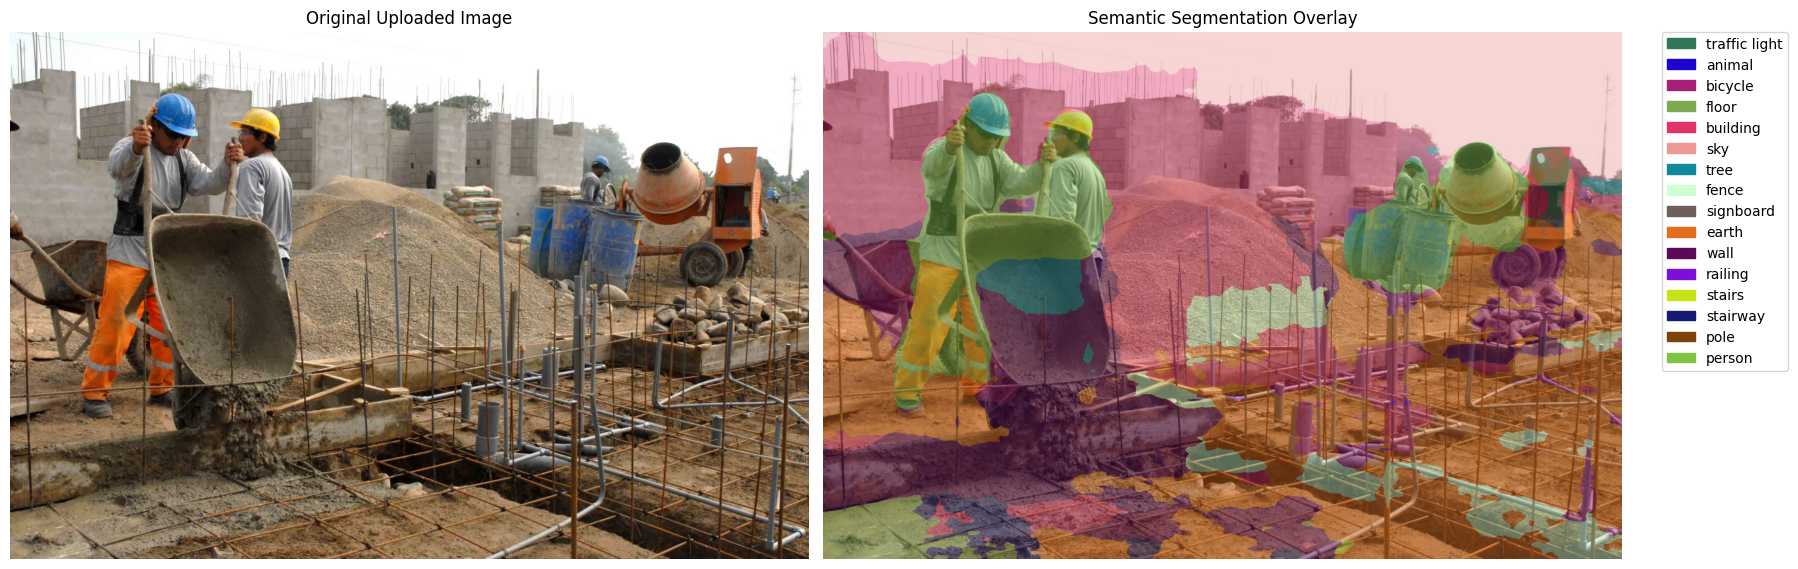

In [25]:
# --- 2. Upload and Load Your Image ---
print("\nPlease upload an image file.")
uploaded = files.upload()

# Check if a file was uploaded
if not uploaded:
    print("\nNo file uploaded. Please run the cell again to upload an image.")
else:
    # Get the filename of the uploaded file
    image_path = list(uploaded.keys())[0]
    # Open the image
    image = Image.open(image_path).convert("RGB")
    print(f"\nSuccessfully loaded image: {image_path}")


    # --- 3. Run Inference ---

    # Get the segmentation masks from the model
    print("Running segmentation on the image...")
    masks = segmenter(image)
    print("Segmentation complete.")


    # --- 4. Visualize the Results ---

    # Create a color map for visualization
    unique_labels = {mask['label'] for mask in masks}
    color_map = {label: list(np.random.choice(range(256), size=3)) for label in unique_labels}

    # Create an empty RGB image to draw the segmentation map
    segmentation_map = np.zeros((image.height, image.width, 3), dtype=np.uint8)

    # Overlay each mask with its corresponding color
    for mask_info in masks:
        label = mask_info['label']
        mask = np.array(mask_info['mask'])
        color = color_map[label]
        segmentation_map[mask > 0] = color

    # Create a blended image for a nice overlay effect
    alpha = 0.6  # Transparency of the overlay
    blended_image = Image.fromarray(
        (alpha * np.array(image) + (1 - alpha) * segmentation_map).astype(np.uint8)
    )

    # --- 5. Display the Images and a Legend ---

    fig, axs = plt.subplots(1, 2, figsize=(18, 9))

    axs[0].imshow(image)
    axs[0].axis('off')
    axs[0].set_title("Original Uploaded Image")

    axs[1].imshow(blended_image)
    axs[1].axis('off')
    axs[1].set_title("Semantic Segmentation Overlay")

    patches = [mpatches.Patch(color=np.array(color)/255, label=label) for label, color in color_map.items()]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

In [ ]:
# Check if a file was uploaded
if not uploaded:
    print("\nNo file uploaded. Please run the cell again to upload an image.")
else:
    # Get the filename of the uploaded file
    image_path = list(uploaded.keys())[0]
    # Open the image
    image = Image.open(image_path).convert("RGB")
    print(f"\nSuccessfully loaded image: {image_path}")


    # --- 3. Run Inference ---

    # Get the segmentation masks from the model
    print("Running segmentation on the image...")
    masks = segmenter(image)
    print("Segmentation complete.")


    # --- 4. Visualize the Results ---

    # Create a color map for visualization
    unique_labels = {mask['label'] for mask in masks}
    color_map = {label: list(np.random.choice(range(256), size=3)) for label in unique_labels}

    # Create an empty RGB image to draw the segmentation map
    segmentation_map = np.zeros((image.height, image.width, 3), dtype=np.uint8)

    # Overlay each mask with its corresponding color
    for mask_info in masks:
        label = mask_info['label']
        mask = np.array(mask_info['mask'])
        color = color_map[label]
        segmentation_map[mask > 0] = color

    # Create a blended image for a nice overlay effect
    alpha = 0.6  # Transparency of the overlay
    blended_image = Image.fromarray(
        (alpha * np.array(image) + (1 - alpha) * segmentation_map).astype(np.uint8)
    )

    # --- 5. Display the Images and a Legend ---

    fig, axs = plt.subplots(1, 2, figsize=(18, 9))

    axs[0].imshow(image)
    axs[0].axis('off')
    axs[0].set_title("Original Uploaded Image")

    axs[1].imshow(blended_image)
    axs[1].axis('off')
    axs[1].set_title("Semantic Segmentation Overlay")

    patches = [mpatches.Patch(color=np.array(color)/255, label=label) for label, color in color_map.items()]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

Loading the segmentation model (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Device set to use cpu


Model loaded successfully.

Please upload an image file.


Saving mineria.jpg to mineria.jpg

Successfully loaded image: mineria.jpg
Running segmentation on the image...
